<a href="https://colab.research.google.com/github/ydegu8133-code/employee-satisfaction-analysis/blob/main/employee_satisfaction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

①データ読み込み

In [1]:
import pandas as pd

df = pd.read_csv("it_employee_satisfaction.csv")
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   employee_id        10 non-null     int64 
 1   gender             10 non-null     object
 2   age                10 non-null     int64 
 3   department         10 non-null     object
 4   position           10 non-null     object
 5   years              10 non-null     int64 
 6   satisfaction       10 non-null     int64 
 7   evaluation         10 non-null     int64 
 8   work_life_balance  10 non-null     int64 
 9   communication      10 non-null     int64 
 10  comment            10 non-null     object
dtypes: int64(7), object(4)
memory usage: 1012.0+ bytes


,0
employee_id,0
gender,0
age,0
department,0
position,0
years,0
satisfaction,0
evaluation,0
work_life_balance,0
communication,0


②前処理

In [2]:
df["comment"] = df["comment"].fillna("")
df["department"] = df["department"].fillna("その他")
df["position"] = df["position"].fillna("不明")

cat_cols = ["gender", "department", "position"]
for col in cat_cols:
    df[col] = df[col].astype("category")


③単純集計

In [3]:
df["department"].value_counts()
df["satisfaction"].describe()
df["work_life_balance"].mean()

np.float64(3.0)

④クロス集計

In [4]:
pd.crosstab(df["department"], df["satisfaction"], normalize="index")
pd.crosstab(df["position"], df["work_life_balance"], normalize="index")

work_life_balance,2,3,4
position,,,
マネージャー,0.5,0.500000,0.000000
リーダー,0.5,0.500000,0.000000
一般,0.0,0.666667,0.333333


⑤可視化

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/l

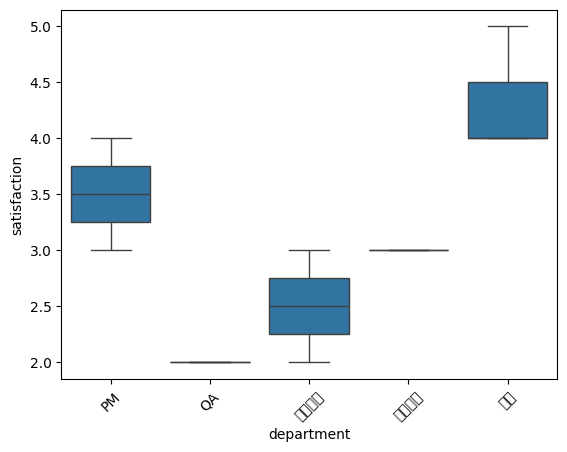

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="department", y="satisfaction", data=df)
plt.xticks(rotation=45)
plt.show()

⑥WordCloud

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,848 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,616 kB]
Get:14 http

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

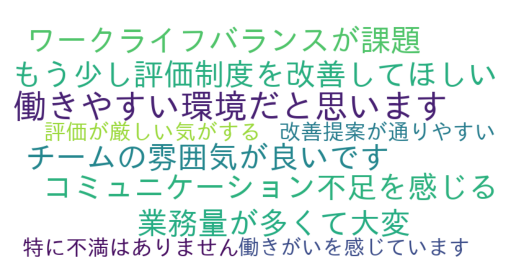

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Update package lists and install a Japanese font for Colab
!sudo apt-get update
!sudo apt-get install -y fonts-takao-gothic
!fc-cache -fv

# Set the font path to the installed font
font_path = '/usr/share/fonts/opentype/takao-gothic/TakaoGothic.ttf'

text = " ".join(df["comment"])
wc = WordCloud(width=800, height=400, background_color="white", font_path=font_path).generate(text)

plt.imshow(wc)
plt.axis("off")